In [1]:
!pip install pycountry --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pycountry

In [3]:
df = pd.read_csv('../data/translated/footnotes_perfect_ukr.csv')

In [4]:
df_persons = pd.read_csv('../data/translated/persons_of_concern_ukr.csv')

In [5]:
# ==========================================
# Фільтруємо ПРИМІТКИ по Україні
# ==========================================

# Створюємо текстовий фільтр: шукаємо "Ukrai" в оригінальному або перекладеному тексті
text_filter = (
    df['Footnote'].str.contains('Ukrai', case=False, na=False) |
    df['Footnote_ukr'].str.contains('Украї', case=False, na=False)
)

# Створюємо код-фільтр за точними ISO кодами країн
code_filter = (
    (df['Country of Origin ISO'] == 'UKR') |
    (df['Country of Asylum ISO'] == 'UKR')
)

# Об'єднуємо обидва фільтри через логічне "АБО" (|)
df_notes = df[code_filter | text_filter]

print(f"Кількість записів про примітки щодо України: {len(df_notes)}")

Кількість записів про примітки щодо України: 31


In [6]:
# ==========================================
# Фільтруємо СТАТИСТИКУ по Україні
# ==========================================

# А. Українці, які виїхали за кордон (Країна походження - Україна)
df_abroad = df_persons[df_persons['Country_of_Origin_ISO'] == 'UKR']

# Б. Внутрішньо переміщені особи (ВПО) всередині України (і походження, і притулок - Україна)
df_idps = df_persons[(df_persons['Country_of_Asylum_ISO'] == 'UKR') & (df_persons['Country_of_Origin_ISO'] == 'UKR')]

print(f"Кількість записів про міграцію українців: {len(df_abroad)}")
print(f"Кількість записів про (ВПО) всередині України: {len(df_idps)}")

Кількість записів про міграцію українців: 559
Кількість записів про (ВПО) всередині України: 8


In [7]:
# ==========================================
# Проводимо АУДИТ якості даних
# ==========================================

# Створення функції аудиту
def audit_dataset(df, name):
    print(f"=== АУДИТ ЯКОСТІ ДАНИХ ДЛЯ: {name} ===")
    print(f"Загальна кількість рядків: {df.shape[0]}")
    print(f"Загальна кількість стовпчиків: {df.shape[1]}\n")

    # 1. Перевірка на повні дублікати рядків
    duplicates = df.duplicated().sum()
    print(f"1. Дублікати: Знайдено {duplicates} повних дублікатів рядків.")

    # 2. Аналіз пропусків (Missing Values)
    print(f"\n2. Пропуски у стовпчиках ({name}):")

    # Порожні/пробільні рядки прирівнюємо до NaN лише для підрахунку —
    # оригінальний df при цьому не змінюється
    df_check = df.replace(r'^\s*$', np.nan, regex=True)

    missing_data = df_check.isnull().sum()
    missing_percent = (df_check.isnull().sum() / len(df_check)) * 100
    missing_table = pd.concat([missing_data, missing_percent], axis=1,
                               keys=['К-сть пропусків', '% пропусків'])
    missing_shown = missing_table[missing_table['К-сть пропусків'] > 0]

    if missing_shown.empty:
        print("   Пропусків не виявлено.")
    else:
        print(missing_shown)

    # 3. Аналіз нульових або від'ємних значень (для числових показників)
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
    if len(numeric_cols) > 0:
        print("\n3. Валідація числових даних (Нулі та аномалії):")
        for col in numeric_cols:
            if col != 'Year': # рік не перевіряємо на нуль
                zeros = (df[col] == 0).sum()
                negatives = (df[col] < 0).sum()
                print(f"   Стовпчик '{col}': нулів — {zeros}, від'ємних значень — {negatives}")
    # 4. Перевірка формату колонки Year — чи всі значення є "чистими" роками,
    #    чи є нестандартні записи (наприклад, діапазони на кшталт "2019-2020")
    if 'Year' in df.columns:
        print("\n4. Перевірка формату колонки 'Year':")
        print(f"   Тип даних колонки: {df['Year'].dtype}")

        def is_pure_year(val):
            try:
                int(str(val).strip())
                return True
            except ValueError:
                return False

        non_standard_mask = ~df['Year'].apply(is_pure_year)
        non_standard_values = df.loc[non_standard_mask, 'Year'].unique()

        print(f"   Нестандартних значень (не чисте число): {non_standard_mask.sum()}")
        if len(non_standard_values) > 0:
            print(f"   Приклади нестандартних значень: {list(non_standard_values)}")

    print("\n" + "="*50 + "\n")

audit_dataset(df_abroad, "Статистика переміщення українців за кордон (df_abroad)")
audit_dataset(df_idps, "Внутрішньо переміщені особи в Україні (df_idps)")
audit_dataset(df_notes, "Примітки щодо України (df_notes)")

=== АУДИТ ЯКОСТІ ДАНИХ ДЛЯ: Статистика переміщення українців за кордон (df_abroad) ===
Загальна кількість рядків: 559
Загальна кількість стовпчиків: 14

1. Дублікати: Знайдено 0 повних дублікатів рядків.

2. Пропуски у стовпчиках (Статистика переміщення українців за кордон (df_abroad)):
   Пропусків не виявлено.

3. Валідація числових даних (Нулі та аномалії):
   Стовпчик 'Refugees': нулів — 87, від'ємних значень — 0
   Стовпчик 'Asylum_Seekers': нулів — 115, від'ємних значень — 0
   Стовпчик 'IDPs': нулів — 551, від'ємних значень — 0
   Стовпчик 'OIP': нулів — 559, від'ємних значень — 0
   Стовпчик 'Stateless': нулів — 559, від'ємних значень — 0
   Стовпчик 'HST': нулів — 559, від'ємних значень — 0
   Стовпчик 'OOC': нулів — 532, від'ємних значень — 0

4. Перевірка формату колонки 'Year':
   Тип даних колонки: int64
   Нестандартних значень (не чисте число): 0


=== АУДИТ ЯКОСТІ ДАНИХ ДЛЯ: Внутрішньо переміщені особи в Україні (df_idps) ===
Загальна кількість рядків: 8
Загальна кількі

In [8]:
# ===============================================================================================
# ОЧИЩЕННЯ df_notes: розгортання діапазонів років та заповнення пропусків у географічних колонках
# ===============================================================================================

# 1. Створюємо копію таблиці нотаток
df_raw_notes = df_notes.copy()

# Перетворюємо стовпчик Year у текстовий формат, щоб безпечно шукати дефіси
df_raw_notes['Year'] = df_raw_notes['Year'].astype(str)

expanded_rows = []

# 2. Перебираємо кожен рядок таблиці та шукаємо діапазони років (наприклад, 2019-2020)
for _, row in df_raw_notes.iterrows():
    year_val = row['Year'].strip()

    if '-' in year_val:  # Якщо знайшли діапазон
        try:
            # Розділяємо роки за дефісом
            start_year, end_year = map(int, year_val.split('-'))
            # Для кожного року з цього діапазону створюємо окремий дублікат рядка
            for y in range(start_year, end_year + 1):
                new_row = row.copy()
                new_row['Year'] = str(y)
                expanded_rows.append(new_row)
        except ValueError:
            # Якщо раптом там інший формат тексту, залишаємо як є
            expanded_rows.append(row)
    else:
       # Якщо це звичайний одиночний рік, записуємо його назад як рядок
        row_copy = row.copy()
        row_copy['Year'] = str(year_val)  # Просто залишаємо рядком, як і було
        expanded_rows.append(row_copy)

# 3. Збираємо новий розширений датафрейм
df_notes = pd.DataFrame(expanded_rows)

# 4. Косметичне очищення порожніх клітинок

cols_to_clean = ['Country of Asylum', 'Country of Asylum ISO', 'Country of Origin', 'Country of Origin ISO']
for col in cols_to_clean:
    df_notes[col] = df_notes[col].replace(r'^\s*$', np.nan, regex=True)

df_notes['Country of Asylum'] = df_notes['Country of Asylum'].fillna('Global data / Other countries')
df_notes['Country of Asylum ISO'] = df_notes['Country of Asylum ISO'].fillna('GLOBAL')
df_notes['Country of Origin'] = df_notes['Country of Origin'].fillna('Global data / Ukraine')
df_notes['Country of Origin ISO'] = df_notes['Country of Origin ISO'].fillna('GLOBAL')

if 'Footnote' in df_notes.columns:
    df_notes = df_notes.drop(columns=['Footnote'])

# 5. Скидання індексів та перетворення типу даних на ціле число
df_notes = df_notes.reset_index(drop=True)
df_notes['Year'] = df_notes['Year'].astype(int)


In [9]:
# ==============================================================
# АГРЕГАЦІЯ: файл 1. Статистика зовнішньої міграції для Power BI
# ==============================================================

# Залишаємо лише потрібні для аналізу внутрішньої ситуації стовпчики
df_abroad = df_abroad[['Year','Country_of_Asylum', 'Country_of_Asylum_ISO', 'Refugees', 'Asylum_Seekers', 'Country_of_Asylum_ukr']]

# Прибираємо порожні рядки
df_abroad = df_abroad[(df_abroad['Refugees'] > 0) | (df_abroad['Asylum_Seekers'] > 0)]

# Додамо колонку числового коду ООН
def get_un_numeric_code(iso3):
    try:
        country = pycountry.countries.get(alpha_3=iso3)
        return country.numeric if country else None
    except Exception:
        return None

unique_iso_codes = df_abroad['Country_of_Asylum_ISO'].dropna().unique()
un_numeric_codes = {code: get_un_numeric_code(code) for code in unique_iso_codes}

df_abroad['Country_of_Asylum_UN_Code'] = df_abroad['Country_of_Asylum_ISO'].map(un_numeric_codes)

# Перевірка: чи всі коди знайдені
missing_codes = df_abroad[df_abroad['Country_of_Asylum_UN_Code'].isna()]['Country_of_Asylum_ISO'].unique()
if len(missing_codes) > 0:
    print(f"Увага: не знайдено UN-код для: {missing_codes}")

df_abroad = df_abroad.reset_index(drop=True)

# ========================================================
# АГРЕГАЦІЯ: файл 2. Статистика внутрішнього переміщення (ВПО та OOC)
# ========================================================
# Залишаємо лише потрібні для аналізу внутрішньої ситуації стовпчики
df_idps = df_idps[['Year', 'Country_of_Asylum', 'IDPs', 'OOC']]

df_idps = df_idps.reset_index(drop=True)


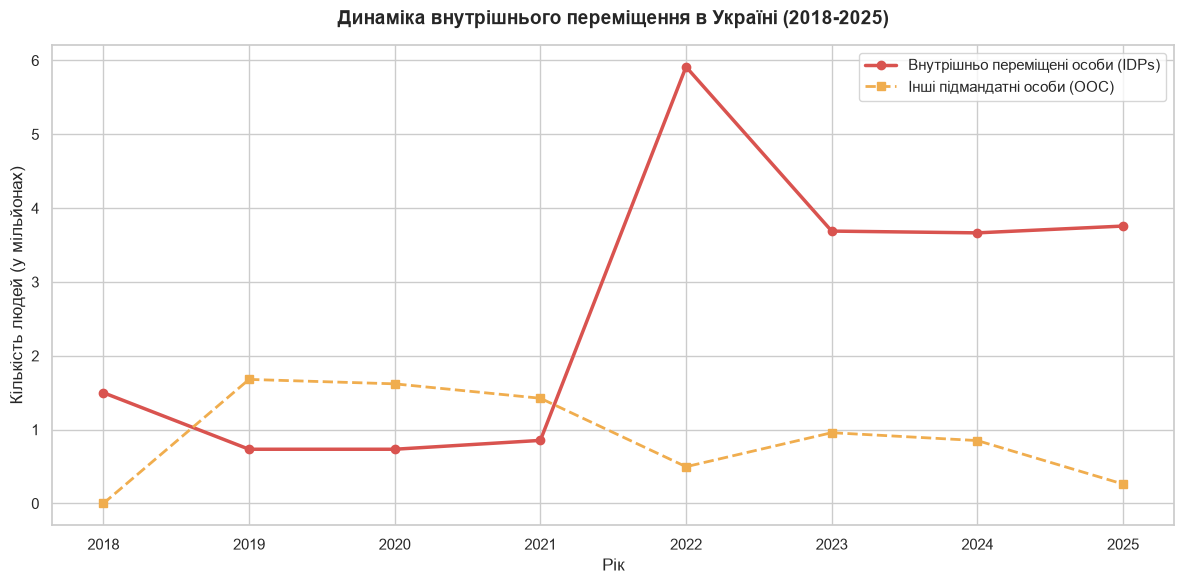

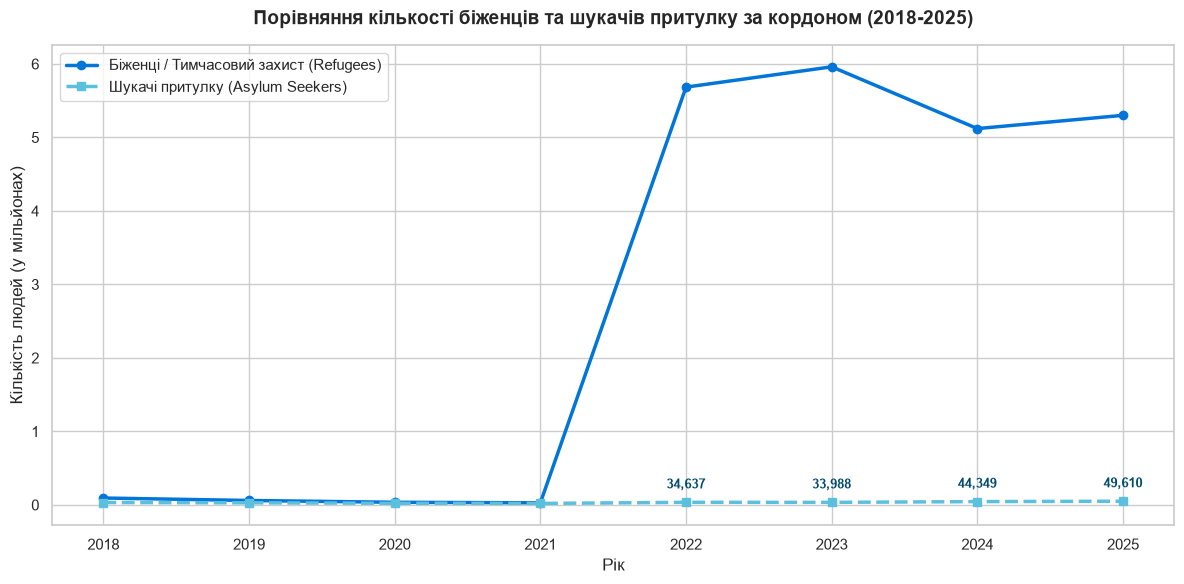

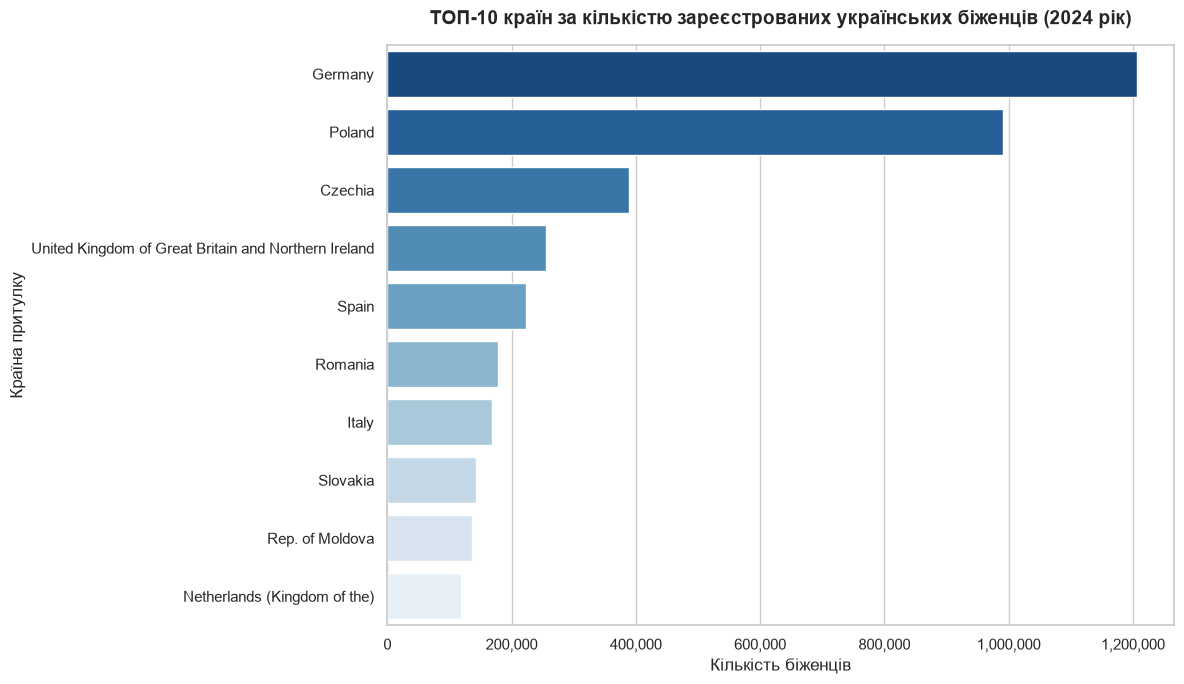

In [10]:
# ==============================================================
# ВІЗУАЛІЗАЦІЯ : попередня, основна в Power BI
# ==============================================================

# Налаштування стилю для графіків
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# === ОБОВ'ЯЗКОВЕ СОРТУВАННЯ ЗА РОКАМИ ДЛЯ ПРАВИЛЬНОЇ ХРОНОЛОГІЇ ===
df_idps = df_idps.sort_values(by='Year').reset_index(drop=True)
df_abroad = df_abroad.sort_values(by='Year').reset_index(drop=True)

# ========================================================
# ГРАФІК 1: Динаміка внутрішнього переміщення (ВПО та OOC)
# ========================================================
df_idps_yearly = df_idps.groupby('Year')[['IDPs', 'OOC']].sum().reset_index()
df_idps_yearly = df_idps_yearly.sort_values(by='Year').reset_index(drop=True)

# Переводимо значення у мільйони для кращої читабельності
df_idps_yearly['IDPs_M'] = df_idps_yearly['IDPs'] / 1_000_000
df_idps_yearly['OOC_M'] = df_idps_yearly['OOC'] / 1_000_000

plt.figure()
plt.plot(df_idps_yearly['Year'], df_idps_yearly['IDPs_M'], marker='o', linewidth=2.5, color='#d9534f', label='Внутрішньо переміщені особи (IDPs)')
plt.plot(df_idps_yearly['Year'], df_idps_yearly['OOC_M'], marker='s', linewidth=2, linestyle='--', color='#f0ad4e', label='Інші підмандатні особи (OOC)')

plt.title('Динаміка внутрішнього переміщення в Україні (2018-2025)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Рік', fontsize=12)
plt.ylabel('Кількість людей (у мільйонах)', fontsize=12)
# Робимо так, щоб відображався кожен рік на осі X без пропусків
plt.xticks(df_idps['Year'].unique())
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# ========================================================
# ГРАФІК 2: Структура зовнішньої міграції (Біженці vs Шукачі притулку)
# ========================================================

df_abroad_yearly = df_abroad.groupby('Year')[['Refugees', 'Asylum_Seekers']].sum().reset_index()
df_abroad_yearly = df_abroad_yearly.sort_values(by='Year').reset_index(drop=True)

# Переводимо значення у мільйони для кращої читабельності
df_abroad_yearly['Refugees_M'] = df_abroad_yearly['Refugees'] / 1_000_000
df_abroad_yearly['Asylum_Seekers_M'] = df_abroad_yearly['Asylum_Seekers'] / 1_000_000

# Будуємо графік з двома окремими лініями від нуля
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Лінія для Біженців
plt.plot(df_abroad_yearly['Year'], df_abroad_yearly['Refugees_M'],
         marker='o', linewidth=2.5, color='#0275d8', label='Біженці / Тимчасовий захист (Refugees)')

# Лінія для Шукачів притулку
plt.plot(df_abroad_yearly['Year'], df_abroad_yearly['Asylum_Seekers_M'],
         marker='s', linewidth=2.5, color='#5bc0de', linestyle='--', label='Шукачі притулку (Asylum Seekers)')

# Налаштування осей та підписів
plt.title('Порівняння кількості біженців та шукачів притулку за кордоном (2018-2025)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Рік', fontsize=12)
plt.ylabel('Кількість людей (у мільйонах)', fontsize=12)
plt.xticks(df_abroad_yearly['Year'].unique())

# Додаємо точні цифри підказок для шукачів притулку після 2022 року, щоб їх було видно
for i, txt in enumerate(df_abroad_yearly['Asylum_Seekers']):
    if df_abroad_yearly['Year'][i] >= 2022:
        plt.annotate(f"{txt:,}", (df_abroad_yearly['Year'][i], df_abroad_yearly['Asylum_Seekers_M'][i]),
                     textcoords="offset points", xytext=(0,10), ha='center', fontsize=9, color='#004b6e', fontweight='bold')

plt.legend(fontsize=11, loc='upper left')
plt.tight_layout()
plt.show()

# ========================================================
# ГРАФІК 3: ТОП-10 країн за кількістю українських біженців у 2024 році
# ========================================================
df_2024 = df_abroad[df_abroad['Year'] == 2024]
df_top10_2024 = df_2024.groupby('Country_of_Asylum')['Refugees'].sum().nlargest(10).reset_index()

plt.figure(figsize=(12, 7))
sns.barplot(x='Refugees', y='Country_of_Asylum', data=df_top10_2024, hue='Country_of_Asylum', palette='Blues_r', legend=False)

plt.title('ТОП-10 країн за кількістю зареєстрованих українських біженців (2024 рік)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Кількість біженців', fontsize=12)
plt.ylabel('Країна притулку', fontsize=12)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.tight_layout()
plt.show()

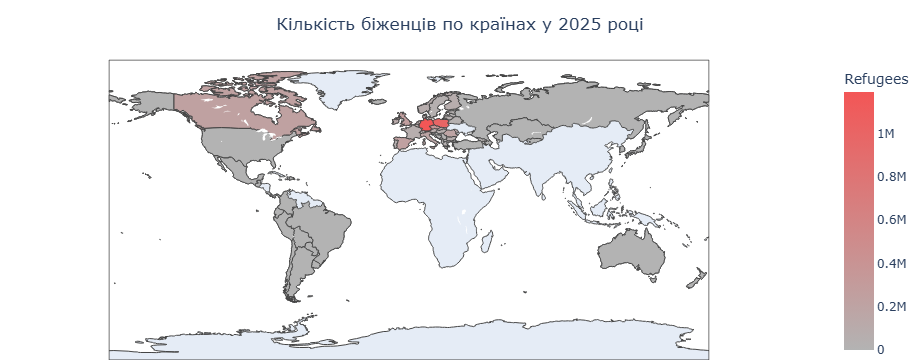

In [11]:
import plotly.express as px

# Створюємо кастомний градієнт від червоного до сірого
# (якщо потрібно навпаки, щоб більше біженців було червонішим, поміняйте їх місцями: ["#808080", "#F35656"])
custom_scale = ["#B3B3B3", "#F35656"]

# Створюємо окремий датафрейм за 2025 рік, де кількість біженців більше 0
df_2025 = df_abroad[(df_abroad["Year"] == 2025) & (df_abroad["Refugees"] > 0)]

fig = px.choropleth(
    df_2025,
    locations="Country_of_Asylum_ISO",         # Стовпчик з назвами країн
    color="Refugees",                          # Колір залежить від кількості біженців
    hover_name="Country_of_Asylum_ISO",        # Назва при наведенні
    color_continuous_scale=custom_scale,       # Наш кастомний градієнт
    title='Кількість біженців по країнах у 2025 році',
)

fig.update_layout(title_x=0.5, margin={"r":0,"t":60,"l":0,"b":0}) # Прибираємо зайві поля
fig.show()

In [12]:
# ========================================================
# ФАЙЛ 1: Агрегована статистика зовнішньої міграції для Power BI
# ========================================================

# Зберігаємо файл
df_abroad = df_abroad.sort_values(by='Year').reset_index(drop=True)
df_abroad.to_csv("../data/processed/BI_ukrainian_abroad_final.csv", index=False, encoding="utf-8-sig")

# ========================================================
# ФАЙЛ 2: Статистика внутрішнього переміщення (ВПО та OOC)
# ========================================================

# Зберігаємо файл
df_idps = df_idps.sort_values(by='Year').reset_index(drop=True)
df_idps.to_csv("../data/processed/BI_ukrainian_idps.csv", index=False, encoding="utf-8-sig")

# ========================================================
# ФАЙЛ 3: ПРИМІТКИ по Україні
# ========================================================

# Зберігаємо файл
df_notes.to_csv("../data/processed/BI_ukrainian_notes.csv", index=False, encoding="utf-8-sig")
